
## Dataset: Telco Customer Churn

Data Quality Assessment is the process of identifying problems in a dataset before performing further analysis or machine learning.

In this notebook, we will investigate:

- Missing Values
- Duplicate Records
- Invalid Values

The objective is to identify data-quality issues that may affect data analysis and machine learning models.

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Missing Values

Missing values occur when information is not available or has not been recorded for an observation.

Identifying missing values is important because they can affect statistical analysis and machine learning models.

We will check:

- Number of missing values
- Percentage of missing values
- Missing values by column
- Missing value patterns

### 1.1 Number of Missing Values

We can use `isnull()` and `sum()` to count missing values in each column.

### Observation

The result shows the number of missing values present in each column.

Columns with missing values require further investigation before performing analysis or building machine learning models.

### 1.2 Percentage of Missing Values

The percentage of missing values helps us understand how much of each column's data is missing.

In [3]:
# Percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


### 1.3 Missing Values by Column

We can create a summary containing both the number and percentage of missing values for each column.

In [4]:
# Create a missing-value summary

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Values,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


### 1.4 Missing Value Patterns

A missing-value pattern helps us understand where missing values occur across the dataset.

A heatmap can be used to visually inspect missing values.

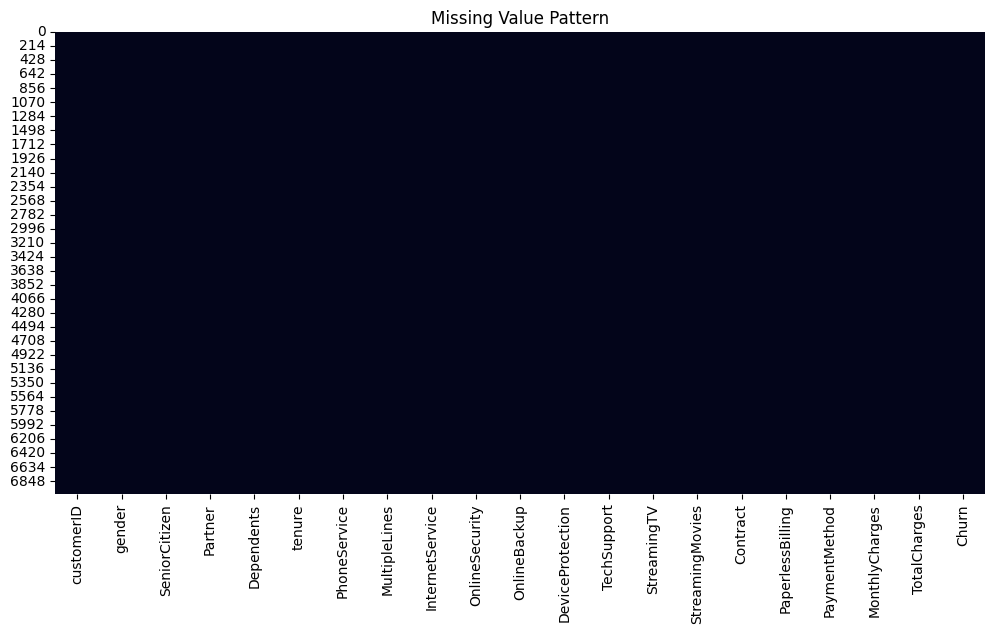

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Value Pattern")
plt.show()

## 2. Duplicate Records

Duplicate records are repeated observations in a dataset.

Duplicates can affect analysis and may cause the same observation to be counted multiple times.

We will:

- Identify duplicates
- Count duplicates
- Display completely duplicated rows
- Investigate potential duplicate records

### 2.1 Identify Duplicates

The `duplicated()` method identifies rows that are duplicates of previous rows.

In [6]:
# Identify duplicate rows

df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
7038,False
7039,False
7040,False
7041,False


In [7]:
### 2.2 Count Duplicates

In [8]:
# Count duplicate rows

df.duplicated().sum()

np.int64(0)

### 2.3 Display Completely Duplicated Rows

We can display rows that are completely duplicated across all columns.

In [ ]:
### 2.3 Display Completely Duplicated Rows

We can display rows that are completely duplicated across all columns.

In [9]:
# Display completely duplicated rows

df[df.duplicated(keep=False)]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


### 2.4 Potential Duplicate Records

Not all duplicate records are completely identical.

Two records may represent the same customer or entity even if some values are different.

For example, duplicate customer information can be investigated using columns such as customer name, phone number, email address, or other identifying attributes when available.

## 3. Invalid Values

Invalid values are values that do not follow the expected rules or meaning of a variable.

Examples include:

- Negative values where they are not appropriate
- Impossible values
- Incorrect categories
- Invalid dates
- Incorrect data types
- Unexpected values
- Empty strings
- Null-like values

### 3.1 Negative Values

Some variables should not contain negative values.

For example, `tenure` and `MonthlyCharges` should not normally be negative.

We can check these values using conditions.

In [10]:
# Check for negative tenure values

df[df["tenure"] < 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [11]:
# Check for negative MonthlyCharges

df[df["MonthlyCharges"] < 0]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


### Observation

No negative values are expected for `tenure` or `MonthlyCharges`.

If negative values were found, they would require investigation because they would not represent valid customer information.

### 3.2 Impossible and Unexpected Values

We can inspect unique values and their frequencies for categorical variables to identify unexpected categories.

In [12]:
# Check categories in selected categorical columns

print("Gender:")
print(df["gender"].value_counts())

print("\nContract:")
print(df["Contract"].value_counts())

print("\nInternetService:")
print(df["InternetService"].value_counts())

print("\nChurn:")
print(df["Churn"].value_counts())

Gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Contract:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

Churn:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### 3.3 Incorrect Data Types

Data types should match the meaning of the variables.

For example, `TotalCharges` represents a numerical value, but in this dataset it is stored as an object data type.

This is a potential data-quality issue that should be investigated.

In [13]:
# Check data types

df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [14]:
# Check the TotalCharges column

df["TotalCharges"].head(10)

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
5,820.5
6,1949.4
7,301.9
8,3046.05
9,3487.95


### 3.4 Empty Strings

Empty strings may represent missing information.

We can check how many empty strings are present in each column.

In [15]:
# Count empty strings in each column

(df == "").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### 3.5 Null-like Values

Sometimes missing values are represented using values such as `NA`, `N/A`, `null`, `None`, or `?` instead of actual `NaN` values.

These values should be identified and handled appropriately.

In [17]:
# Check for common null-like values

null_like_values = ["NA", "N/A", "null", "None", "?"]

for value in null_like_values:
    print(f"{value}:")
    print((df == value).sum().sum())

NA:
0
N/A:
0
null:
0
None:
0
?:
0


# Data Quality Assessment Summary

The Telco Customer Churn dataset was investigated for common data-quality issues.

The assessment included:

- Missing value counts and percentages
- Missing value patterns
- Duplicate records
- Completely duplicated rows
- Potential duplicate records
- Negative values
- Impossible or unexpected values
- Incorrect categories
- Incorrect data types
- Empty strings
- Null-like values

The inspection helps identify problems that should be addressed before further exploratory data analysis, preprocessing, and machine learning.